In [ ]:
import pandas as pd

# 1. Load Data
url = "https://raw.githubusercontent.com/thecont1/namma-metro-ridership-tracker/main/NammaMetro_Ridership_Dataset.csv"
df = pd.read_csv(url)

# 2. Show Available Columns
print("--- AVAILABLE COLUMNS ---")
print(list(df.columns))
print("\n")

# 3. Clean Data (Fill missing numeric values with 0 to allow calculation)
numeric_cols = ['Total Smart Cards', 'Stored Value Card', 'Total Tokens', 'Total QR', 'Total NCMC']
df[numeric_cols] = df[numeric_cols].fillna(0)

# Calculate 'Total Ridership' for better analysis
df['Total_Ridership'] = df[numeric_cols].sum(axis=1)

# 4. Calculate Mean, Median, Mode
print("--- DESCRIPTIVE STATISTICS (Total Ridership) ---")
mean_val = df['Total_Ridership'].mean()
median_val = df['Total_Ridership'].median()
mode_val = df['Total_Ridership'].mode()[0]
std_val = df['Total_Ridership'].std()

print(f"Mean (Average):   {mean_val:,.2f}")
print(f"Median (Typical): {median_val:,.2f}")
print(f"Mode (Frequent):  {mode_val:,.2f}")
print(f"Std Dev (Var):    {std_val:,.2f}")

# 5. Basic Insights
print("\n--- INITIAL INSIGHTS ---")
if mean_val > median_val:
    print("Insight: The Mean > Median. This indicates 'Right Skewness'.")
    print("Interpretation: Most days have normal ridership, but a few 'peak' days (likely special events/holidays) are pulling the average up.")
elif mean_val < median_val:
    print("Insight: The Mean < Median. This indicates 'Left Skewness'.")
    print("Interpretation: A few very low-traffic days (likely strikes or shutdowns) are dragging the average down.")
else:
    print("Insight: Mean ≈ Median. The data is fairly symmetrical (Normal Distribution).")

--- AVAILABLE COLUMNS ---
['Record Date', 'Total Smart Cards', 'Stored Value Card', 'One Day Pass', 'Three Day Pass', 'Five Day Pass', 'Total Tokens', 'Total NCMC', 'Group Ticket', 'Total QR', 'QR NammaMetro', 'QR WhatsApp', 'QR Paytm']


--- DESCRIPTIVE STATISTICS (Total Ridership) ---
Mean (Average):   1,164,413.64
Median (Typical): 1,248,489.00
Mode (Frequent):  498,405.00
Std Dev (Var):    233,113.77

--- INITIAL INSIGHTS ---
Insight: The Mean < Median. This indicates 'Left Skewness'.
Interpretation: A few very low-traffic days (likely strikes or shutdowns) are dragging the average down.


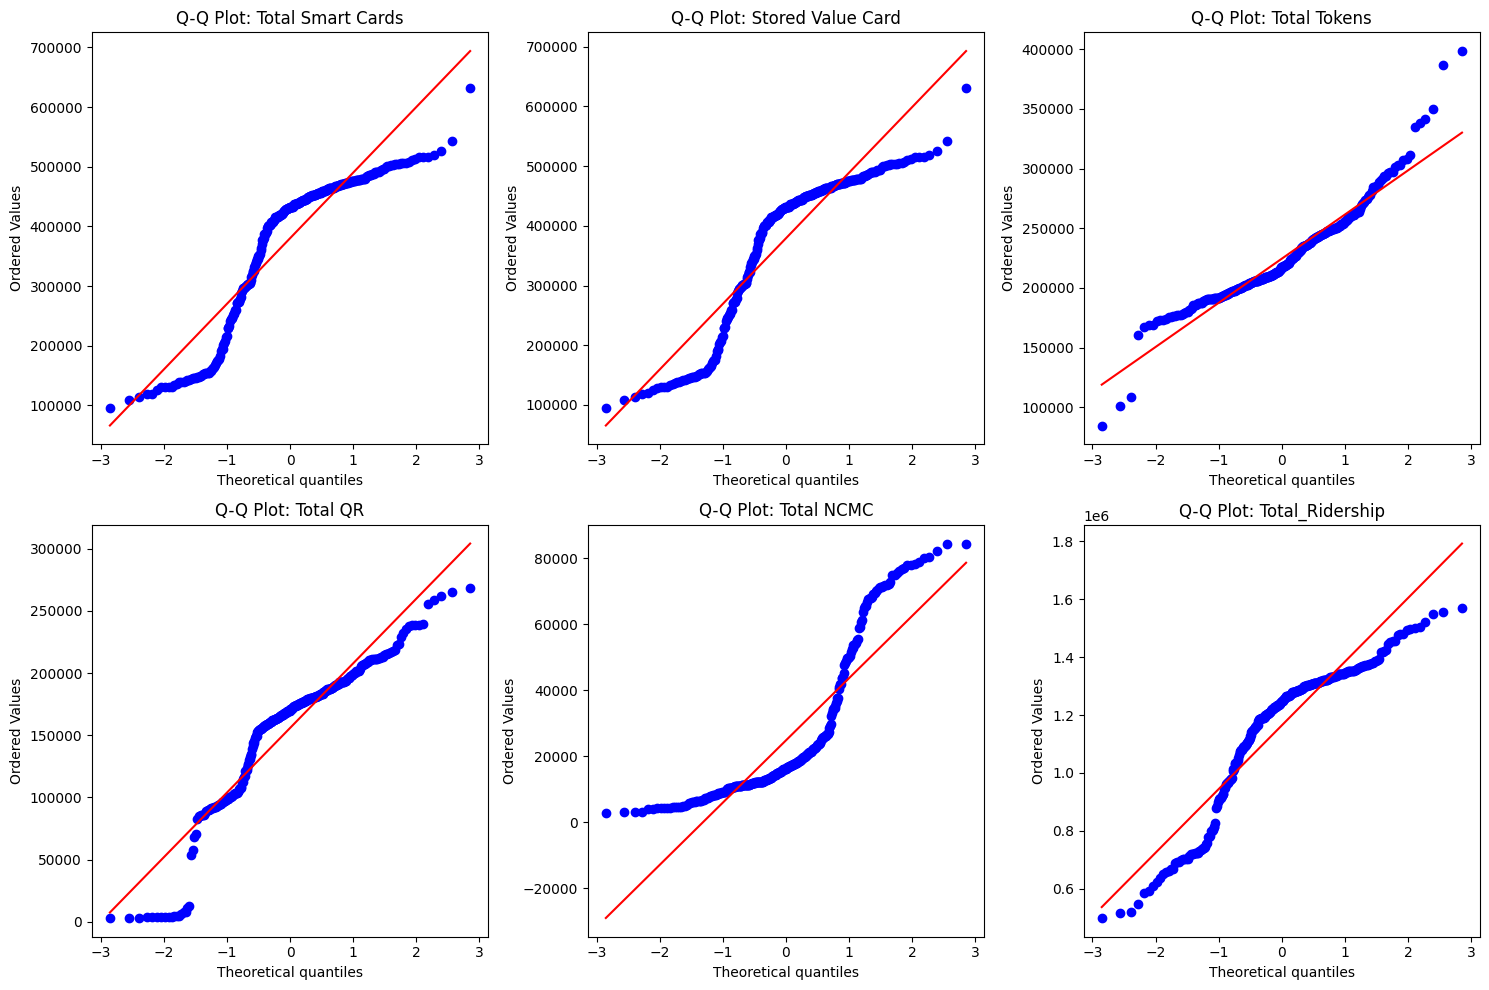

In [ ]:

import matplotlib.pyplot as plt
import scipy.stats as stats


cols = ['Total Smart Cards', 'Stored Value Card', 'Total Tokens', 'Total QR', 'Total NCMC']
df['Total_Ridership'] = df[cols].sum(axis=1)
cols.append('Total_Ridership')

# 2. Plot
plt.figure(figsize=(15, 10))
for i, col in enumerate(cols):
    ax = plt.subplot(2, 3, i + 1)
    stats.probplot(df[col], dist="norm", plot=ax)
    ax.set_title(f'Q-Q Plot: {col}')

plt.tight_layout()
plt.show()

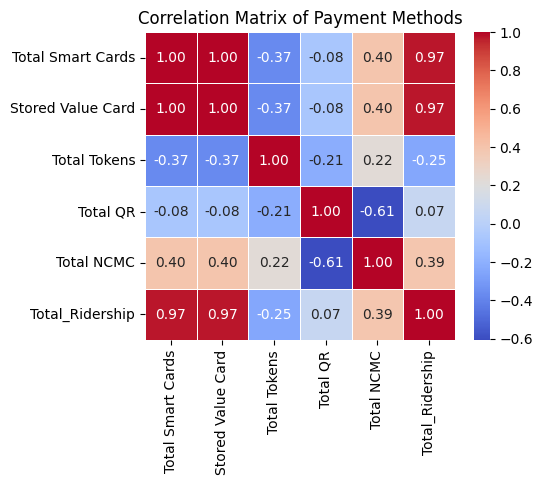

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure data is numeric for correlation
corr_matrix = df[cols].corr()

# 2. Plot Heatmap
plt.figure(figsize=(5,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Payment Methods')
plt.show()

In [ ]:
import pandas as pd
from scipy.stats import ttest_rel

# 1. Identify Numeric Columns
cols = ['Total Smart Cards', 'Stored Value Card', 'Total Tokens', 'Total QR', 'Total NCMC']
# Ensure we only use columns that actually exist in your dataframe
check_cols = [c for c in cols if c in df.columns]

# 2. Find the "Best Correlated" Pair
corr_matrix = df[check_cols].corr().abs()

# Set diagonal to 0 so we don't find self-correlation (which is always 1.0)
for i in range(len(corr_matrix)):
    corr_matrix.iloc[i, i] = 0

# Get the pair with the highest value
max_corr = corr_matrix.max().max()
col1, col2 = corr_matrix.stack().idxmax()  # Returns the names of the two columns

print(f"Top Correlation: {max_corr:.4f} (Between '{col1}' and '{col2}')")

# 3. Perform Paired T-Test
# H0 (Null Hypothesis): The average volume of both methods is the same.
stat, p = ttest_rel(df[col1], df[col2])

print(f"\n--- PAIRED T-TEST RESULTS ({col1} vs {col2}) ---")
print(f"T-Statistic: {stat:.2f}")
print(f"P-Value:     {p:.5f}")

print("-" * 40)
if p < 0.05:
    print("CONCLUSION: SIGNIFICANT DIFFERENCE.")
    print("Explanation: Even though they are highly correlated (they rise/fall together), one method has significantly higher volume than the other.")
else:
    print("CONCLUSION: NO SIGNIFICANT DIFFERENCE.")
    print("Explanation: The volume of users for both methods is statistically similar.")

Top Correlation: 1.0000 (Between 'Total Smart Cards' and 'Stored Value Card')

--- PAIRED T-TEST RESULTS (Total Smart Cards vs Stored Value Card) ---
T-Statistic: 48.38
P-Value:     0.00000
----------------------------------------
CONCLUSION: SIGNIFICANT DIFFERENCE.
Explanation: Even though they are highly correlated (they rise/fall together), one method has significantly higher volume than the other.


In [ ]:
import pandas as pd
from scipy.stats import ttest_ind

# 1. Identify Numeric Columns
cols = ['Total Smart Cards', 'Stored Value Card', 'Total Tokens', 'Total QR', 'Total NCMC']
# Ensure we check only columns that exist
check_cols = [c for c in cols if c in df.columns]

# 2. Find Best Correlated Pair
corr_matrix = df[check_cols].corr().abs()

# Set diagonal to 0 (ignore self-correlation)
for i in range(len(corr_matrix)):
    corr_matrix.iloc[i, i] = 0

max_corr = corr_matrix.max().max()
col1, col2 = corr_matrix.stack().idxmax()

print(f"Top Correlation: {max_corr:.4f} (Between '{col1}' and '{col2}')")

# 3. Perform Welch's T-Test (Independent, Unequal Variance)
# H0: The means of both groups are equal.
stat, p = ttest_ind(df[col1], df[col2], equal_var=False)

print(f"\n--- WELCH'S T-TEST RESULTS ({col1} vs {col2}) ---")
print(f"T-Statistic: {stat:.2f}")
print(f"P-Value:     {p:.5f}")
print("-" * 40)

if p < 0.05:
    print("CONCLUSION: SIGNIFICANT DIFFERENCE.")
    print(f"Explanation: Although '{col1}' and '{col2}' are highly correlated (they go up/down together), their actual volume (count) is significantly different.")
else:
    print("CONCLUSION: NO SIGNIFICANT DIFFERENCE.")
    print("Explanation: The average volume of users for both methods is statistically the same.")

Top Correlation: 1.0000 (Between 'Total Smart Cards' and 'Stored Value Card')

--- WELCH'S T-TEST RESULTS (Total Smart Cards vs Stored Value Card) ---
T-Statistic: 0.09
P-Value:     0.92862
----------------------------------------
CONCLUSION: NO SIGNIFICANT DIFFERENCE.
Explanation: The average volume of users for both methods is statistically the same.


In [ ]:
from scipy.stats import ttest_ind
import pandas as pd

# 1. Load Data
# Assuming 'df' is already loaded. If not, uncomment the line below:
# df = pd.read_csv("https://raw.githubusercontent.com/thecont1/namma-metro-ridership-tracker/main/NammaMetro_Ridership_Dataset.csv")

# 2. Pre-processing
df['Record Date'] = pd.to_datetime(df['Record Date'], dayfirst=True)
df['Is_Weekend'] = df['Record Date'].dt.weekday >= 5 # True if Sat/Sun

# Split into two groups
weekdays = df[df['Is_Weekend'] == False]
weekends = df[df['Is_Weekend'] == True]

# 3. Perform T-Test for Each Attribute
cols = ['Total Smart Cards', 'Stored Value Card', 'Total Tokens', 'Total QR', 'Total NCMC']

print(f"{'ATTRIBUTE':<25} | {'T-STAT':<8} | {'P-VALUE':<10} | {'CONCLUSION'}")
print("-" * 65)

for col in cols:
    # Run Independent T-Test
    # equal_var=False performs Welch's T-Test (safer for real-world data)
    stat, p = ttest_ind(weekdays[col], weekends[col], equal_var=False)

    conclusion = "Significant Diff." if p < 0.05 else "Same (No Diff.)"
    print(f"{col:<25} | {stat:<8.2f} | {p:<10.5f} | {conclusion}")

ATTRIBUTE                 | T-STAT   | P-VALUE    | CONCLUSION
-----------------------------------------------------------------
Total Smart Cards         | 19.97    | 0.00000    | Significant Diff.
Stored Value Card         | 19.98    | 0.00000    | Significant Diff.
Total Tokens              | -7.29    | 0.00000    | Significant Diff.
Total QR                  | -3.01    | 0.00319    | Significant Diff.
Total NCMC                | 7.92     | 0.00000    | Significant Diff.


--- ANOVA TEST RESULTS ---
F-Statistic: 78.22
P-Value:     0.00000
CONCLUSION: SIGNIFICANT DIFFERENCE.
Explanation: The day of the week DOES affect how many people travel.


/tmp/ipython-input-3979967248.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Day_Name', y='Total_Ridership', data=df, order=days_order, palette='viridis')


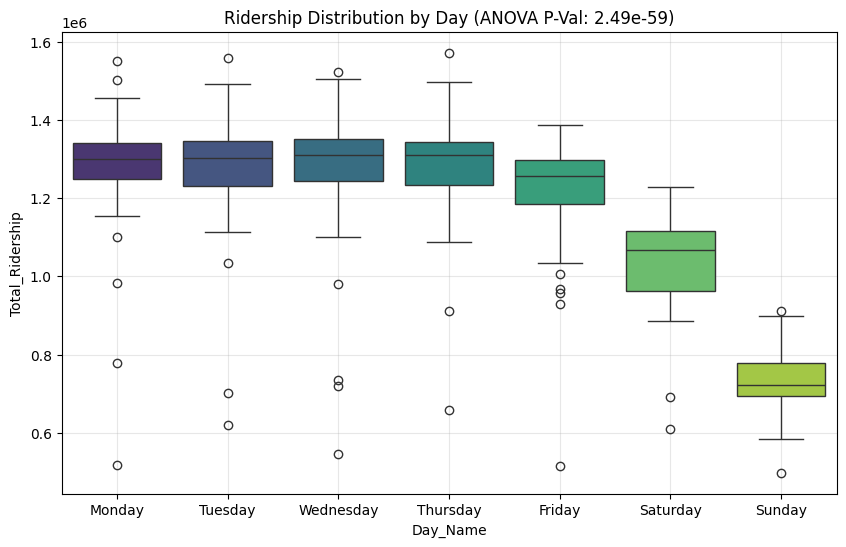

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway

# 1. Prepare Data
# Create a 'Day Name' column (Monday, Tuesday...)
df['Record Date'] = pd.to_datetime(df['Record Date'], dayfirst=True)
df['Day_Name'] = df['Record Date'].dt.day_name()

# Organize data into groups for the test
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
groups = [df[df['Day_Name'] == day]['Total_Ridership'] for day in days_order]

# 2. Perform One-Way ANOVA
# H0: The mean ridership is the same for all days.
f_stat, p_val = f_oneway(*groups)

print(f"--- ANOVA TEST RESULTS ---")
print(f"F-Statistic: {f_stat:.2f}")
print(f"P-Value:     {p_val:.5f}")

if p_val < 0.05:
    print("CONCLUSION: SIGNIFICANT DIFFERENCE.")
    print("Explanation: The day of the week DOES affect how many people travel.")
else:
    print("CONCLUSION: NO DIFFERENCE.")

# 3. Visualize (Boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(x='Day_Name', y='Total_Ridership', data=df, order=days_order, palette='viridis')
plt.title(f'Ridership Distribution by Day (ANOVA P-Val: {p_val:.2e})')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency

# 1. Prepare Data
# Create 'Day Type' category
df['Record Date'] = pd.to_datetime(df['Record Date'], dayfirst=True)
df['Day_Type'] = df['Record Date'].apply(lambda x: 'Weekend' if x.weekday() >= 5 else 'Weekday')

# Select the Payment Methods (Categories) we want to compare
payment_cols = ['Total Smart Cards', 'Total Tokens', 'Total QR']

# 2. Create Contingency Table (Observed Frequencies)
# We sum up the total users for each method, grouped by Day Type
contingency_table = df.groupby('Day_Type')[payment_cols].sum()

print("--- CONTINGENCY TABLE (Observed Counts) ---")
print(contingency_table)
print("-" * 50)

# 3. Perform Chi-Square Test
# H0: Payment Method is INDEPENDENT of Day Type (Ratios are same).
# Ha: Payment Method DEPENDS on Day Type (Preference changes).
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2:.2f}")
print(f"P-Value:              {p:.5f}")

print("-" * 50)
if p < 0.05:
    print("CONCLUSION: SIGNIFICANT RELATIONSHIP (Reject H0).")
    print("Explanation: The type of ticket people buy DEPENDS on whether it's a Weekday or Weekend.")
    print("(e.g., Casual travelers on weekends might prefer Tokens/QR over Smart Cards).")
else:
    print("CONCLUSION: NO RELATIONSHIP (Fail to reject H0).")
    print("Explanation: People choose ticket types in the same proportions, regardless of the day.")

--- CONTINGENCY TABLE (Observed Counts) ---
          Total Smart Cards  Total Tokens  Total QR
Day_Type                                           
Weekday           102686873      50984259  35592914
Weekend            18918297      20874426  14283531
--------------------------------------------------
Chi-Square Statistic: 6250973.21
P-Value:              0.00000
--------------------------------------------------
CONCLUSION: SIGNIFICANT RELATIONSHIP (Reject H0).
Explanation: The type of ticket people buy DEPENDS on whether it's a Weekday or Weekend.
(e.g., Casual travelers on weekends might prefer Tokens/QR over Smart Cards).


In [ ]:
import pandas as pd
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 1. Prepare Data
# Ensure we have the Day Name column
df['Record Date'] = pd.to_datetime(df['Record Date'], dayfirst=True)
df['Day_Name'] = df['Record Date'].dt.day_name()

print("--- TUKEY'S HSD (Pairwise Comparison) ---")
print("Checking which specific days differ from each other...")

# 2. Run Tukey's Test
# endog = Data (Ridership), groups = Groups (Day Names)
tukey = pairwise_tukeyhsd(endog=df['Total_Ridership'], groups=df['Day_Name'], alpha=0.05)

# 3. Show Results
print(tukey.summary())

# Explanation of the Output
print("\n--- HOW TO READ THIS ---")
print("1. Look at the 'reject' column.")
print("2. True = These two days are SIGNIFICANTLY different.")
print("3. False = These two days are statistically the same.")
print("   (e.g., Mon vs Tue might be False, but Mon vs Sun will be True).")

--- TUKEY'S HSD (Pairwise Comparison) ---
Checking which specific days differ from each other...
          Multiple Comparison of Means - Tukey HSD, FWER=0.05          
 group1    group2    meandiff   p-adj     lower        upper     reject
-----------------------------------------------------------------------
  Friday    Monday    64544.422 0.3222  -24257.3402  153346.1843  False
  Friday  Saturday -172761.4073    0.0   -264075.88  -81446.9346   True
  Friday    Sunday -477735.2697    0.0 -572111.9565 -383358.5829   True
  Friday  Thursday     73793.52 0.1968  -16979.6647  164566.7047  False
  Friday   Tuesday    66695.907 0.3022  -23556.4864  156948.3003  False
  Friday Wednesday   56071.6817 0.5126  -33679.2499  145822.6133  False
  Monday  Saturday -237305.8293    0.0 -329055.4178 -145556.2408   True
  Monday    Sunday -542279.6918    0.0 -637077.4401 -447481.9435   True
  Monday  Thursday     9249.098 0.9999  -81961.7848  100459.9808  False
  Monday   Tuesday    2151.4849    1.0 

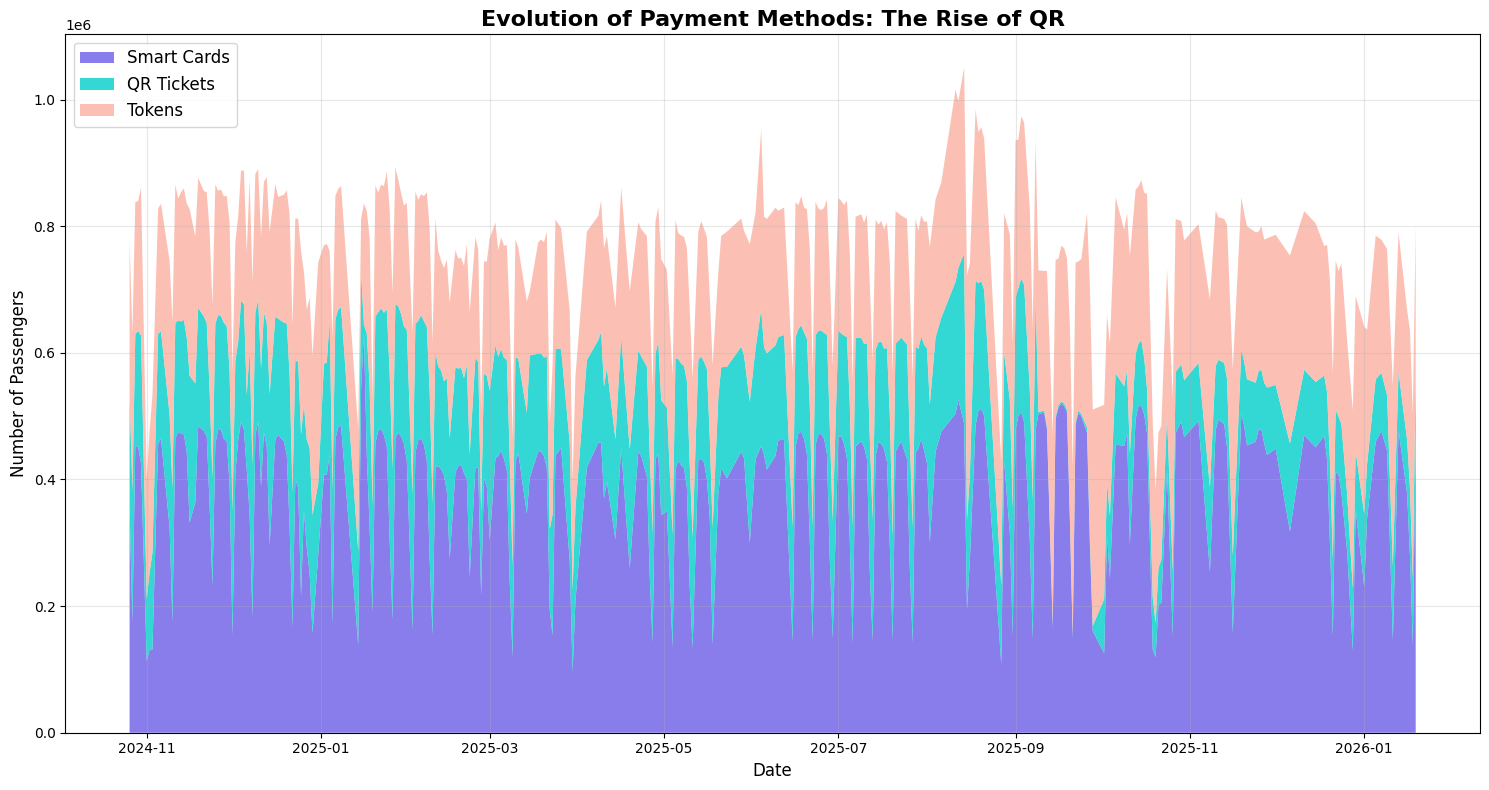

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare Data for Plotting
# We need the data sorted by date
df_sorted = df.sort_values('Record Date')

x = df_sorted['Record Date']
y1 = df_sorted['Total Smart Cards']
y2 = df_sorted['Total QR']
y3 = df_sorted['Total Tokens']

# 2. Create Stacked Area Chart
plt.figure(figsize=(15, 8))

# We stack them: Cards on bottom, QR in middle, Tokens on top
plt.stackplot(x, y1, y2, y3,
              labels=['Smart Cards', 'QR Tickets', 'Tokens'],
              colors=['#6c5ce7', '#00cec9', '#fab1a0'],
              alpha=0.8)

plt.title('Evolution of Payment Methods: The Rise of QR', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
plt.legend(loc='upper left', fontsize=12)
plt.grid(True, alpha=0.3)

# Add a text annotation pointing to a recent trend if you want
# plt.text(x.iloc[-30], y1.iloc[-30], 'Smart Cards Dominating', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

/tmp/ipython-input-2503900139.py:10: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_ts = df_ts.asfreq('D').fillna(method='ffill')
/tmp/ipython-input-2503900139.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_ts = df_ts.asfreq('D').fillna(method='ffill')


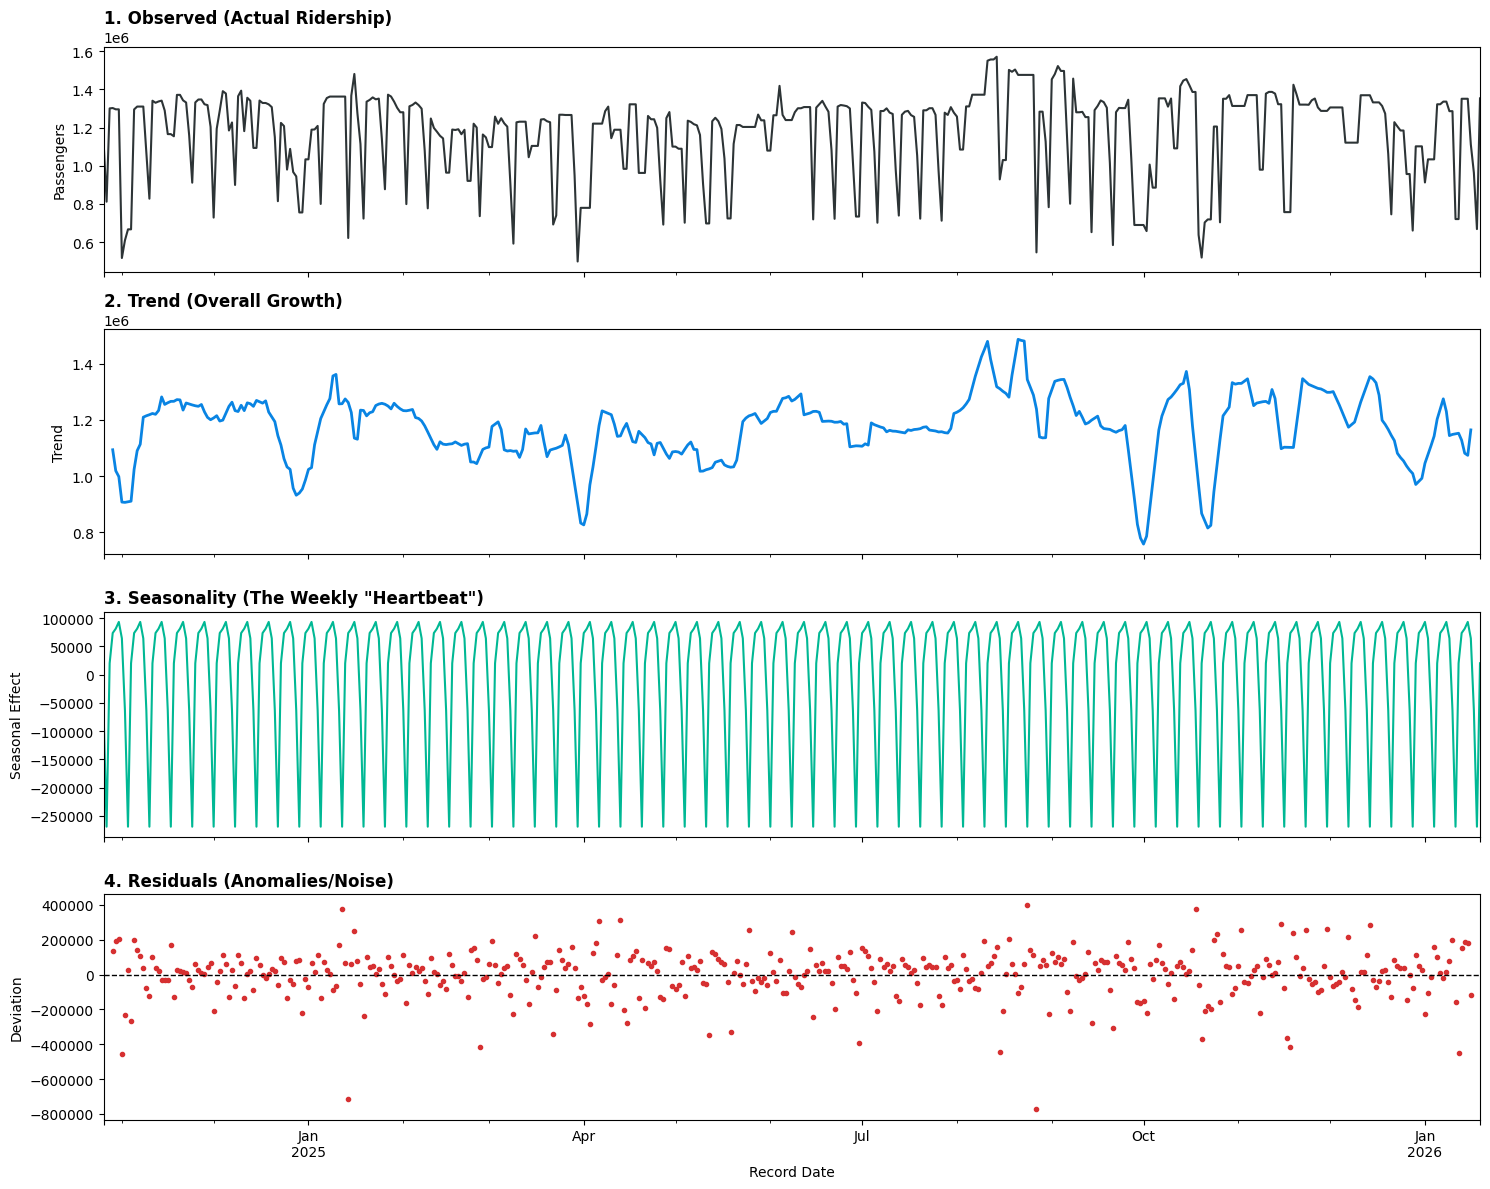

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Prepare Data (Must have a Datetime Index)
df['Record Date'] = pd.to_datetime(df['Record Date'], dayfirst=True)
df_ts = df.set_index('Record Date')

# We need a continuous frequency. Since we have daily data, we fill missing dates if any.
df_ts = df_ts.asfreq('D').fillna(method='ffill')

# 2. Decompose
# period=7 because the pattern repeats every 7 days (Weekly)
result = seasonal_decompose(df_ts['Total_Ridership'], model='additive', period=7)

# 3. Plot
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(15, 12), sharex=True)

# Observed (Actual Data)
result.observed.plot(ax=ax1, color='#2d3436')
ax1.set_title('1. Observed (Actual Ridership)', fontweight='bold', loc='left')
ax1.set_ylabel('Passengers')

# Trend (General Direction)
result.trend.plot(ax=ax2, color='#0984e3', linewidth=2)
ax2.set_title('2. Trend (Overall Growth)', fontweight='bold', loc='left')
ax2.set_ylabel('Trend')

# Seasonality (Weekly Pattern)
result.seasonal.plot(ax=ax3, color='#00b894')
ax3.set_title('3. Seasonality (The Weekly "Heartbeat")', fontweight='bold', loc='left')
ax3.set_ylabel('Seasonal Effect')

# Residuals (Noise/Anomalies)
result.resid.plot(ax=ax4, color='#d63031', linestyle='None', marker='.')
ax4.axhline(0, color='black', linestyle='--', linewidth=1)
ax4.set_title('4. Residuals (Anomalies/Noise)', fontweight='bold', loc='left')
ax4.set_ylabel('Deviation')

plt.tight_layout()
plt.show()

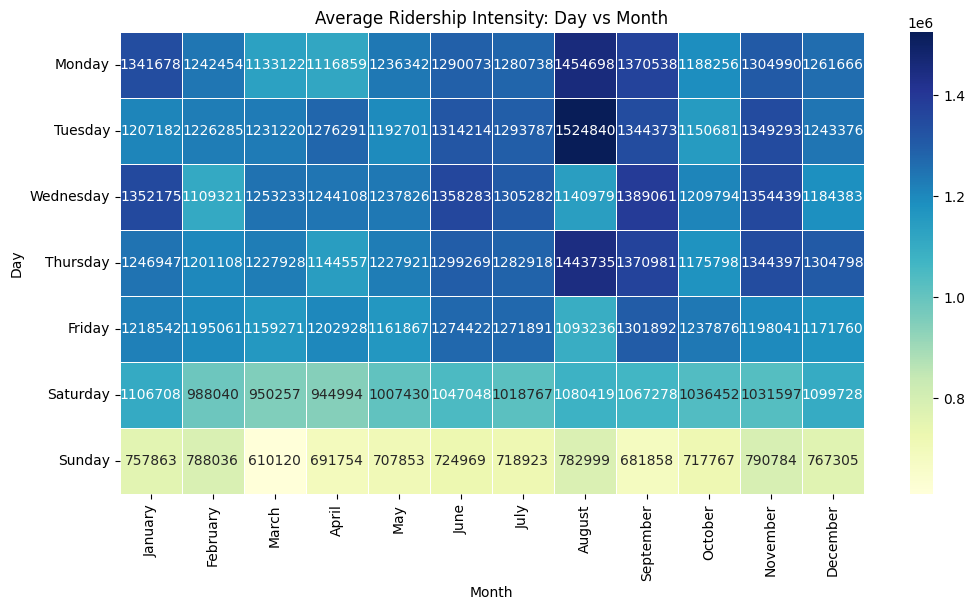

In [ ]:
import seaborn as sns

# 1. Prepare Data
df['Month'] = df['Record Date'].dt.month_name()
df['Day'] = df['Record Date'].dt.day_name()
df['Month_Num'] = df['Record Date'].dt.month

# Sort orders for proper plotting
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
months_order = df.sort_values('Month_Num')['Month'].unique()

# 2. Pivot Data
pivot = df.pivot_table(index='Day', columns='Month', values='Total_Ridership', aggfunc='mean')

# Reorder indices
pivot = pivot.reindex(days_order)
pivot = pivot[months_order]

# 3. Plot Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(pivot, cmap='YlGnBu', annot=True, fmt=".0f", linewidths=0.5)
plt.title('Average Ridership Intensity: Day vs Month')
plt.yticks(rotation=0)
plt.show()